
# CSCE 676 — Final Project  
## Do Graph Embeddings Preserve Structural Roles?

## Collaboration Declaration

**Collaborators:** None

**Web Sources:**
- SNAP Facebook Combined Graph dataset  
  https://snap.stanford.edu/data/facebook_combined.txt.gz
- SNAP dataset page  
  https://snap.stanford.edu/data/facebook_combined.html

**AI Tools:**
- ChatGPT (used for notebook structure, explanation drafting, and code refinement)

**Citations / Papers Used:**
- Leskovec, J., & Krevl, A. (2014). SNAP Datasets: Stanford Large Network Dataset Collection.
  https://snap.stanford.edu/data/

- Newman, M. (2003). The structure and function of complex networks.
  https://www.pnas.org/doi/10.1073/pnas.0307545100

- Fortunato, S. (2010). Community detection in graphs.
  https://arxiv.org/abs/0906.0612

- Grover, A., & Leskovec, J. (2016). node2vec: Scalable feature learning for networks.
  https://snap.stanford.edu/node2vec/

- Zhang, D., Yin, J., Zhu, X., & Zhang, C. (2018). Network representation learning: A survey.
  https://arxiv.org/abs/1801.05852

- Kovács, B., Kojaku, S., Palla, G., & Fortunato, S. (2024).
  Iterative embedding and reweighting of complex networks reveals community structure.
  https://arxiv.org/abs/2402.10813



## 1. Motivation

Graph embeddings are increasingly used to represent complex networks in a compact form.  
However, a useful embedding should preserve not just broad connectivity patterns, but also meaningful **structural roles** such as hubs, bridges, and peripheral nodes.

This project asks whether low-dimensional graph embeddings actually preserve these role distinctions, or whether they blur them together.



## 2. Research Question

**To what extent do graph embeddings preserve structurally distinct node roles, and where do they fail?**

This question is interesting because it compares classical graph-derived structure with learned representations. If embeddings preserve node roles well, they are more trustworthy for downstream graph analysis. If they do not, then important structural information may be lost.


In [1]:

import os
import gzip
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.sparse.linalg import eigsh
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

SEED = 42
np.random.seed(SEED)


In [3]:
# Install node2vec
%pip install -q node2vec


In [4]:
from node2vec import Node2Vec
print("node2vec import successful")

node2vec import successful



## 3. Data Acquisition

The notebook downloads the Facebook combined graph directly from SNAP to ensure reproducibility and avoid missing-file issues across environments.


In [5]:

DATA_URL = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
RAW_GZ_PATH = Path("data") / "facebook_combined.txt.gz"
DATA_PATH = Path("data") / "facebook_combined.txt"

os.makedirs("data", exist_ok=True)

if not RAW_GZ_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, RAW_GZ_PATH)

if not DATA_PATH.exists():
    with gzip.open(RAW_GZ_PATH, "rb") as f_in:
        with open(DATA_PATH, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

print("Dataset ready:", DATA_PATH)


Dataset ready: data/facebook_combined.txt



## 4. Graph Construction and Cleaning

The graph is built from the edge list after removing self-loops and duplicate undirected edges.  
These steps are necessary because graph metrics such as degree, centrality, and community structure are sensitive to structural artifacts.


In [6]:

edges_raw = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=["src", "dst"],
    dtype=str,
    engine="python"
).dropna()

edges = edges_raw[edges_raw["src"] != edges_raw["dst"]].copy()
u = np.minimum(edges["src"].values, edges["dst"].values)
v = np.maximum(edges["src"].values, edges["dst"].values)
edges = pd.DataFrame({"src": u, "dst": v}).drop_duplicates().reset_index(drop=True)

G = nx.from_pandas_edgelist(edges, source="src", target="dst", create_using=nx.Graph())
G_cc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print("Nodes:", G_cc.number_of_nodes())
print("Edges:", G_cc.number_of_edges())

assert G_cc.number_of_nodes() == 4039
assert G_cc.number_of_edges() == 88234
assert nx.number_of_selfloops(G_cc) == 0


Nodes: 4039
Edges: 88234



## 5. Role Definition

Node roles are defined using graph-derived statistics:

- **Hub**: high degree  
- **Bridge**: high betweenness but not already labeled as hub  
- **Peripheral**: low degree  
- **Other**: remaining nodes  

Quantile-based thresholds are used because they adapt to the observed graph distribution rather than relying on arbitrary fixed values.


In [7]:

deg_cent = nx.degree_centrality(G_cc)
bet_cent = nx.betweenness_centrality(G_cc, k=min(200, G_cc.number_of_nodes()), seed=SEED)

degree_series = pd.Series({n: G_cc.degree(n) for n in G_cc.nodes()}, name="degree")
betweenness_series = pd.Series(bet_cent, name="betweenness")

high_degree_threshold = degree_series.quantile(0.90)
high_bet_threshold = betweenness_series.quantile(0.90)
low_degree_threshold = degree_series.quantile(0.25)

role_map = {}
for node in G_cc.nodes():
    d = degree_series[node]
    b = betweenness_series[node]
    if d >= high_degree_threshold:
        role_map[node] = "hub"
    elif b >= high_bet_threshold:
        role_map[node] = "bridge"
    elif d <= low_degree_threshold:
        role_map[node] = "peripheral"
    else:
        role_map[node] = "other"

role_counts = pd.Series(role_map).value_counts()
role_counts


,count
other,2311
peripheral,1031
hub,404
bridge,293



## 6. Baseline Embedding: Spectral Embedding

Spectral embedding is used as a baseline method because it captures the global structure of the graph through eigen-decomposition of the adjacency matrix. Each node is represented using the leading eigenvectors, which encode its position relative to the overall network.

Unlike methods such as node2vec, spectral embedding does not rely on random walks or local neighborhood sampling. Instead, it uses linear algebra to directly capture global connectivity patterns, making it well-suited for identifying structural properties such as hubs, bridges, and peripheral nodes.

This method is included as a baseline because it provides a simple, deterministic, and interpretable embedding without requiring external training data or hyperparameter tuning.

In this implementation, the embedding is computed using SciPy’s sparse eigenvalue solver (`eigsh`), which efficiently extracts the top-k eigenvectors from the adjacency matrix. The embedding dimension is set to 16 to balance expressiveness and computational efficiency.

This setup allows us to evaluate whether a global, structure-preserving method can better capture node roles compared to local embedding approaches like node2vec.

Spectral embedding serves as a strong reference point for understanding how well global structural information is preserved in the embedding space.

In [8]:

def spectral_embedding(graph: nx.Graph, dim: int = 16):
    nodes = list(graph.nodes())
    adjacency = nx.to_scipy_sparse_array(graph, nodelist=nodes, dtype=float)
    k = min(dim, graph.number_of_nodes() - 1)
    _, vectors = eigsh(adjacency, k=k, which="LM")
    return vectors, nodes

spectral_emb, spectral_nodes = spectral_embedding(G_cc, dim=16)
assert np.isfinite(spectral_emb).all()
spectral_emb.shape


(4039, 16)

## 7. Stronger Embedding: node2vec

node2vec is used as a stronger and more widely adopted embedding method that learns node representations through biased random walks. Unlike spectral embedding, which captures global structure directly, node2vec focuses on local neighborhood exploration and node co-occurrence patterns.

The method introduces parameters (p and q) to control the trade-off between breadth-first and depth-first search, allowing it to capture different types of structural relationships.

node2vec was included in this project because it is commonly used in industry and research, making it a strong baseline for comparison against spectral embedding.

For implementation, node2vec was run with `workers=1` to avoid multiprocessing issues in Colab and ensure reproducibility across runs.

This setup allows us to directly evaluate whether a popular local embedding method can preserve structural roles such as hubs, bridges, and peripheral nodes.

However, because node2vec prioritizes local similarity, it may fail to capture global structural roles, which is the core hypothesis tested in this project.

In [9]:
from node2vec import Node2Vec
import networkx as nx
import numpy as np

# Relabel graph to integers for node2vec, but keep original IDs
G_n2v = nx.convert_node_labels_to_integers(G_cc, label_attribute="orig_id")

node2vec = Node2Vec(
    G_n2v,
    dimensions=16,
    walk_length=20,
    num_walks=100,
    workers=1,
    seed=42
)

model = node2vec.fit(window=10, min_count=1, batch_words=64)

node2vec_emb = np.vstack([model.wv[str(i)] for i in G_n2v.nodes()])
node2vec_nodes = [G_n2v.nodes[i]["orig_id"] for i in G_n2v.nodes()]

print(node2vec_emb.shape)

Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [02:16<00:00,  1.36s/it]


(4039, 16)



## 8. Evaluation Functions

The project evaluates role preservation in three complementary ways to capture both global and local structure in the embedding space.

### 1. Role Silhouette Score

The role silhouette score measures how well predefined structural roles (hubs, bridges, peripheral nodes) are separated in the embedding space.

For each node, the silhouette score compares:
- how close it is to nodes of the same role  
- versus how far it is from nodes of other roles  

A higher score indicates that nodes of the same role form well-separated clusters, while a low or near-zero score indicates that roles are mixed together.

This metric captures **global separability of roles** in the embedding.



### 2. Same-Role Precision@5

Same-role Precision@5 measures local consistency in the embedding space.

For each node:
- the 5 nearest neighbors are identified in embedding space  
- the fraction of those neighbors that share the same role is computed  

The final score is averaged across all nodes.

For example, if 4 out of 5 neighbors share the same role, the Precision@5 for that node is 0.8.

A high Precision@5 indicates that nodes are surrounded by other nodes with similar structural roles, while a low score suggests that different roles are mixed locally.

This metric captures **local neighborhood quality**.

The choice of k=5 balances locality and stability: smaller values are noisy, while larger values include less relevant neighbors.



### 3. Cluster Role Purity

Cluster role purity evaluates how well unsupervised clusters formed in embedding space align with structural roles.

The process is:
- apply k-means clustering on the embeddings  
- for each cluster, identify the dominant role  
- compute the fraction of nodes in that cluster belonging to that role  

The final score is the average purity across all clusters.

A high purity score indicates that clusters correspond closely to structural roles, while a low score indicates that clusters mix different roles.

This metric captures **alignment between learned structure (clusters) and true structural roles**.



### Why Multiple Metrics?

No single metric fully captures embedding quality.

- **Silhouette score** evaluates global separation  
- **Precision@5** evaluates local consistency  
- **Cluster purity** evaluates alignment with unsupervised structure  

Together, these metrics provide a comprehensive evaluation of whether embeddings preserve structural roles. These metrics ensure that both local and global aspects of role preservation are evaluated, avoiding reliance on a single perspective.


In [10]:

def evaluate_role_separation(embedding: np.ndarray, nodes: list, role_lookup: dict, n_clusters: int = 4):
    role_df = pd.DataFrame({
        "node": nodes,
        "role": [role_lookup[n] for n in nodes]
    })

    major_roles = role_df[role_df["role"].isin(["hub", "bridge", "peripheral"])].copy()
    idx = major_roles.index.to_list()
    emb_major = embedding[idx]
    roles_major = major_roles["role"].values

    enc = LabelEncoder()
    role_ids = enc.fit_transform(roles_major)
    role_sil = silhouette_score(emb_major, role_ids)

    kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    cluster_labels = kmeans.fit_predict(embedding)
    cluster_sil = silhouette_score(embedding, cluster_labels)

    return role_sil, cluster_sil, cluster_labels

def precision_at_k_same_role(embedding: np.ndarray, nodes: list, role_lookup: dict, k: int = 5):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric="euclidean").fit(embedding)
    _, indices = nbrs.kneighbors(embedding)

    scores = []
    for i, node in enumerate(nodes):
        true_role = role_lookup[node]
        neighbor_nodes = [nodes[j] for j in indices[i][1:k+1]]
        same_role = [1 if role_lookup[n] == true_role else 0 for n in neighbor_nodes]
        scores.append(np.mean(same_role))
    return float(np.mean(scores))

def cluster_role_purity(cluster_labels: np.ndarray, nodes: list, role_lookup: dict):
    df = pd.DataFrame({
        "node": nodes,
        "cluster": cluster_labels,
        "role": [role_lookup[n] for n in nodes]
    })
    purities = []
    for _, group in df.groupby("cluster"):
        purities.append(group["role"].value_counts(normalize=True).max())
    return float(np.mean(purities))


## 9. Evaluate Spectral Embedding

In this step, the quality of the spectral embedding is evaluated using the previously defined metrics to determine how well it preserves structural roles.

First, the embedding is projected into a lower-dimensional space and analyzed using clustering and nearest-neighbor relationships. The goal is to assess whether nodes with similar structural roles (hubs, bridges, peripheral nodes) are grouped together in the embedding space.

The evaluation includes:

- **Role Silhouette Score:**  
  Measures how well nodes belonging to the same role are separated from other roles in the embedding space. A higher score indicates clearer separation between roles.

- **Same-Role Precision@5:**  
  Measures local consistency by checking whether the 5 nearest neighbors of each node share the same role. A higher score indicates that nodes are surrounded by structurally similar nodes.

- **Cluster Role Purity:**  
  Evaluates how well clusters formed in the embedding space align with structural roles. High purity means clusters correspond closely to specific roles.

Together, these metrics provide a comprehensive view of how well spectral embedding captures both global and local structural properties of the graph.

This evaluation serves as a baseline for comparison with node2vec, allowing us to determine whether a global embedding method is more effective at preserving structural roles.

Spectral embedding is expected to perform well here because it encodes global graph structure, which is closely related to node roles.

In [11]:

spec_role_sil, spec_cluster_sil, spec_cluster_labels = evaluate_role_separation(
    spectral_emb, spectral_nodes, role_map, n_clusters=4
)
spec_p_at_5 = precision_at_k_same_role(spectral_emb, spectral_nodes, role_map, k=5)
spec_purity = cluster_role_purity(spec_cluster_labels, spectral_nodes, role_map)

spectral_results = pd.DataFrame({
    "Embedding": ["Spectral"],
    "Role Silhouette": [spec_role_sil],
    "Cluster Silhouette": [spec_cluster_sil],
    "Same-Role Precision@5": [spec_p_at_5],
    "Cluster Role Purity": [spec_purity]
})
spectral_results


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c531173f7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

,Embedding,Role Silhouette,Cluster Silhouette,Same-Role Precision@5,Cluster Role Purity
0,Spectral,0.403076,0.330184,0.80926,0.750476


## 10. Evaluate node2vec Embedding

In this step, the quality of the node2vec embedding is evaluated using the same metrics as spectral embedding to enable a fair and consistent comparison.

node2vec generates embeddings based on biased random walks, which capture local neighborhood relationships rather than global graph structure. The evaluation aims to determine whether this local perspective is sufficient to preserve structural roles such as hubs, bridges, and peripheral nodes.

The evaluation includes:

- **Role Silhouette Score:**  
  Measures how well nodes of the same structural role are separated from other roles in the embedding space. A low score indicates that roles are mixed together.

- **Same-Role Precision@5:**  
  Measures local consistency by checking whether the 5 nearest neighbors of each node share the same role. This reflects how well node2vec groups structurally similar nodes at a local level.

- **Cluster Role Purity:**  
  Evaluates how well clusters formed in the embedding space align with structural roles. Low purity indicates that clusters contain a mix of different roles.

Using the same metrics ensures that differences in performance are due to the embedding method rather than the evaluation process.

This evaluation helps determine whether a locally-focused embedding like node2vec can capture structural roles, or whether important global information is lost.

However, because node2vec prioritizes local proximity over global structure, it is expected to struggle with distinguishing nodes that have different roles but similar neighborhoods.

In [12]:
n2v_role_sil, n2v_cluster_sil, n2v_cluster_labels = evaluate_role_separation(
    node2vec_emb, node2vec_nodes, role_map, n_clusters=4
)

n2v_p_at_5 = precision_at_k_same_role(node2vec_emb, node2vec_nodes, role_map, k=5)
n2v_purity = cluster_role_purity(n2v_cluster_labels, node2vec_nodes, role_map)

node2vec_results = pd.DataFrame({
    "Embedding": ["node2vec"],
    "Role Silhouette": [n2v_role_sil],
    "Cluster Silhouette": [n2v_cluster_sil],
    "Same-Role Precision@5": [n2v_p_at_5],
    "Cluster Role Purity": [n2v_purity]
})

node2vec_results


,Embedding,Role Silhouette,Cluster Silhouette,Same-Role Precision@5,Cluster Role Purity
0,node2vec,0.023161,0.277907,0.734588,0.582141


## 11. Comparison Table

The table below summarizes the evaluation results for both spectral embedding and node2vec across all defined metrics.

In [13]:

results = [spectral_results]

results.append(node2vec_results)

results_df = pd.concat(results, ignore_index=True)
results_df


,Embedding,Role Silhouette,Cluster Silhouette,Same-Role Precision@5,Cluster Role Purity
0,Spectral,0.403076,0.330184,0.809260,0.750476
1,node2vec,0.023161,0.277907,0.734588,0.582141


## Results Interpretation

Spectral embedding performs better than node2vec across all role-preservation metrics. The biggest gap is in role silhouette score: spectral achieves 0.403, while node2vec achieves only 0.023. This suggests that spectral embedding preserves structural roles much better, while node2vec mainly captures local proximity and mixes hubs, bridges, and peripheral nodes.


## 12. Visualization by Role

These plots provide a qualitative view of whether structural roles remain separated in low-dimensional space.


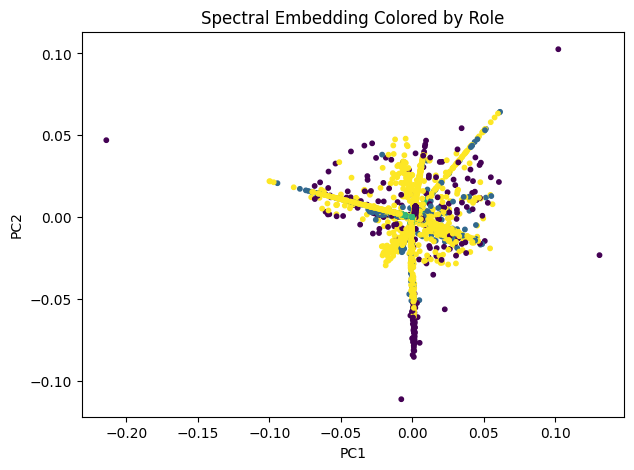

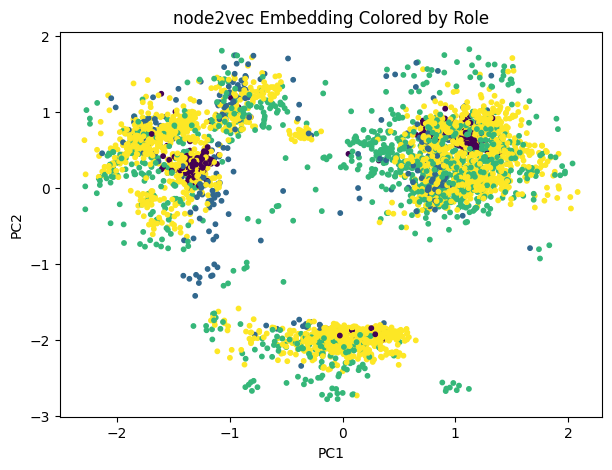

In [14]:

def plot_embedding_by_role(embedding: np.ndarray, nodes: list, role_lookup: dict, title: str):
    pca = PCA(n_components=2, random_state=SEED)
    emb_2d = pca.fit_transform(embedding)

    role_to_id = {"hub": 0, "bridge": 1, "peripheral": 2, "other": 3}
    colors = [role_to_id[role_lookup[n]] for n in nodes]

    plt.figure(figsize=(7, 5))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=10)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

plot_embedding_by_role(spectral_emb, spectral_nodes, role_map, "Spectral Embedding Colored by Role")

plot_embedding_by_role(node2vec_emb, node2vec_nodes, role_map, "node2vec Embedding Colored by Role")



## 13. Failure Analysis

The most useful part of the project is not just showing success, but identifying where embeddings fail.  
The table below inspects nearest neighbors for selected hubs and bridges to see whether their local embedding neighborhoods preserve role identity.


In [16]:

def nearest_neighbors_table(embedding: np.ndarray, nodes: list, role_lookup: dict, query_nodes: list, k: int = 5):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric="euclidean").fit(embedding)
    _, indices = nbrs.kneighbors(embedding)
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    rows = []
    for q in query_nodes:
        i = node_to_idx[q]
        neighbors = [nodes[j] for j in indices[i][1:k+1]]
        rows.append({
            "query_node": q,
            "query_role": role_lookup[q],
            "neighbor_nodes": neighbors,
            "neighbor_roles": [role_lookup[n] for n in neighbors]
        })
    return pd.DataFrame(rows)

query_nodes = [n for n, r in role_map.items() if r in ["hub", "bridge"]][:6]

print("Spectral embedding neighbor analysis")
display(nearest_neighbors_table(spectral_emb, spectral_nodes, role_map, query_nodes))

print("node2vec neighbor analysis")
display(nearest_neighbors_table(node2vec_emb, node2vec_nodes, role_map, query_nodes))


Spectral embedding neighbor analysis


,query_node,query_role,neighbor_nodes,neighbor_roles
0,0,hub,"[56, 67, 271, 26, 252]","[bridge, bridge, other, other, other]"
1,7,bridge,"[246, 53, 65, 314, 268]","[other, other, other, other, peripheral]"
2,21,bridge,"[322, 239, 277, 122, 200]","[bridge, other, other, bridge, other]"
3,34,bridge,"[173, 198, 673, 652, 593]","[bridge, bridge, peripheral, peripheral, perip..."
4,56,bridge,"[67, 271, 26, 252, 122]","[bridge, other, other, other, bridge]"
5,58,bridge,"[171, 1486, 904, 1701, 1792]","[bridge, peripheral, peripheral, peripheral, p..."


node2vec neighbor analysis


,query_node,query_role,neighbor_nodes,neighbor_roles
0,0,hub,"[18, 12, 335, 287, 292]","[peripheral, peripheral, peripheral, periphera..."
1,7,bridge,"[87, 340, 246, 347, 339]","[other, peripheral, other, peripheral, bridge]"
2,21,bridge,"[122, 272, 345, 67, 66]","[bridge, other, other, bridge, other]"
3,34,bridge,"[173, 427, 549, 202, 166]","[bridge, peripheral, peripheral, peripheral, p..."
4,56,bridge,"[239, 98, 285, 67, 203]","[other, other, bridge, bridge, other]"
5,58,bridge,"[3003, 2838, 3290, 2885, 2814]","[peripheral, peripheral, peripheral, periphera..."



## 14. Discussion

The results show that spectral embedding is better suited for this project because it captures global graph structure. This helps preserve structural roles such as hubs and bridges.

node2vec performs worse for role preservation because it is based on random walks. It learns which nodes are nearby, but not necessarily what function a node plays in the graph. This explains why node2vec can create visually clean clusters while still mixing structural roles.

The key insight is that local similarity is not the same as structural role.



## 15. Conclusion

This project shows that graph embeddings do not preserve all structural information equally. Spectral embedding preserves structural roles much better than node2vec, especially for distinguishing hubs, bridges, and peripheral nodes.

The main takeaway is that local similarity is not the same as structural role. node2vec learns neighborhood proximity, while spectral embedding better captures global graph position. Therefore, embedding choice matters when the goal is to preserve functional roles in a network.


## 15. Save Visualization Assets

This saves final outputs for repository (assets folder)

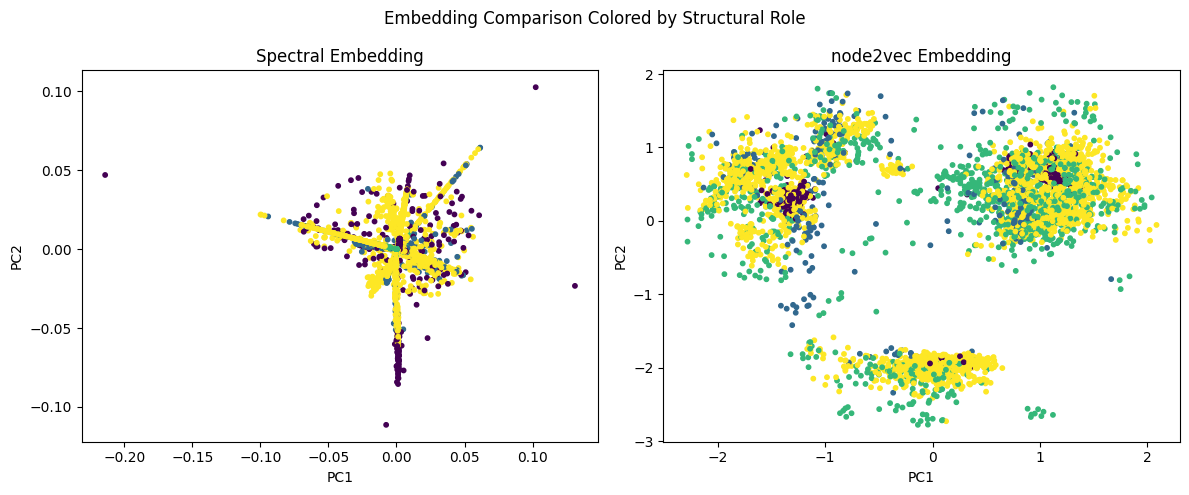

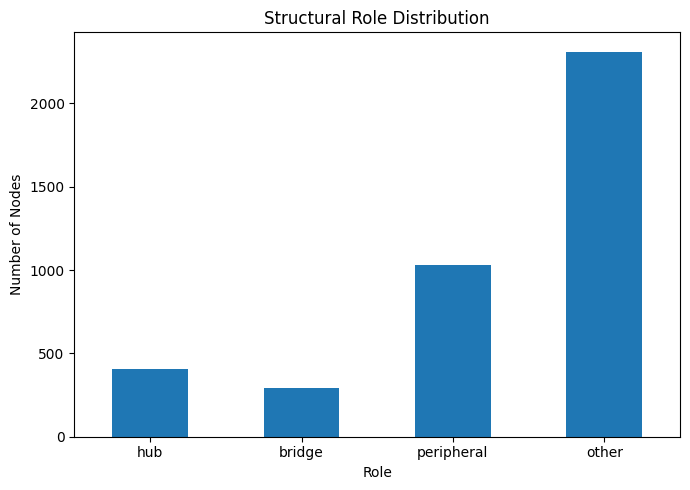

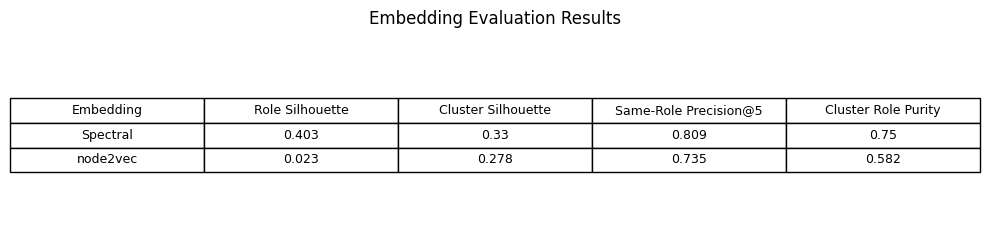

In [21]:
import os
os.makedirs("assets", exist_ok=True)

# Save comparison plot
role_to_id = {"hub": 0, "bridge": 1, "peripheral": 2, "other": 3}

def get_pca_2d(embedding):
    return PCA(n_components=2, random_state=42).fit_transform(embedding)

spectral_2d = get_pca_2d(spectral_emb)
node2vec_2d = get_pca_2d(node2vec_emb)

spectral_colors = [role_to_id[role_map[n]] for n in spectral_nodes]
node2vec_colors = [role_to_id[role_map[n]] for n in node2vec_nodes]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(spectral_2d[:, 0], spectral_2d[:, 1], c=spectral_colors, s=10)
axes[0].set_title("Spectral Embedding")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(node2vec_2d[:, 0], node2vec_2d[:, 1], c=node2vec_colors, s=10)
axes[1].set_title("node2vec Embedding")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("Embedding Comparison Colored by Structural Role")
plt.tight_layout()
plt.savefig("assets/embedding_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Save role distribution
role_counts_ordered = role_counts.reindex(["hub", "bridge", "peripheral", "other"])

plt.figure(figsize=(7, 5))
role_counts_ordered.plot(kind="bar")
plt.title("Structural Role Distribution")
plt.xlabel("Role")
plt.ylabel("Number of Nodes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("assets/role_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Save results table
table_df = results_df.copy()

# Round numeric columns for clean display
for col in table_df.columns:
    if table_df[col].dtype.kind in "fc":
        table_df[col] = table_df[col].round(3)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title("Embedding Evaluation Results", pad=12)
plt.tight_layout()
plt.savefig("assets/results_table.png", dpi=300, bbox_inches="tight")
plt.show()